Airline Recovery

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import plotly.express as px
import nbformat
import plotly.graph_objects as go

In [3]:
recovery = pd.read_csv("Airline_Delay_Cause.csv") 

In [4]:
recovery.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [5]:
recovery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165600 entries, 0 to 165599
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 165600 non-null  int64  
 1   month                165600 non-null  int64  
 2   carrier              165600 non-null  object 
 3   carrier_name         165600 non-null  object 
 4   airport              165600 non-null  object 
 5   airport_name         165600 non-null  object 
 6   arr_flights          165284 non-null  float64
 7   arr_del15            165039 non-null  float64
 8   carrier_ct           165284 non-null  float64
 9   weather_ct           165284 non-null  float64
 10  nas_ct               165284 non-null  float64
 11  security_ct          165284 non-null  float64
 12  late_aircraft_ct     165284 non-null  float64
 13  arr_cancelled        165284 non-null  float64
 14  arr_diverted         165284 non-null  float64
 15  arr_delay        

In [6]:
recovery.dropna(inplace=True)

In [7]:
#group months by quater
recovery['quarter'] = ((recovery['month'] - 1) // 3) + 1

In [ ]:
#recovery['quarter'].unique()
recovery['carrier_name'].unique()

array(['Allegiant Air', 'GoJet Airlines LLC d/b/a United Express',
       'Hawaiian Airlines Network', 'Envoy Air', 'Spirit Airlines',
       'PSA Airlines Inc.', 'SkyWest Airlines Inc.', 'Piedmont Airlines',
       'Endeavor Air Inc.', 'American Airlines Network',
       'Alaska Airlines Network', 'JetBlue Airways',
       'CommuteAir LLC dba CommuteAir', 'Delta Air Lines Network',
       'Frontier Airlines', 'Horizon Air', 'United Air Lines Network',
       'Southwest Airlines', 'Mesa Airlines Inc.', 'Republic Airline',
       'Air Wisconsin Airlines Corp',
       'Commutair Aka Champlain Enterprises, Inc.',
       'Empire Airlines Inc.', 'ExpressJet Airlines LLC',
       'Trans States Airlines', 'Compass Airlines',
       'Peninsula Airways Inc.', 'ExpressJet Airlines Inc.', 'Cape Air',
       'Virgin America'], dtype=object)

In [8]:
#Filter relevant years for analysis
filtered = recovery[recovery['year'].isin([2018, 2019, 2020, 2021, 2022, 2023, 2024])]

In [9]:
#filter baseline years - pre covid years
filtered_pre = recovery[recovery['year'].isin([2019])]

In [10]:
#filter post covid years
filtered_post = recovery[recovery['year'].isin([2024])]

In [11]:
filtered_covid = recovery[recovery['year'].isin([2020, 2021, 2022])]

In [12]:
recovery_by_month_post = filtered_post.groupby('carrier_name')['arr_flights'].sum().nlargest(10)

recovery_post = recovery_by_month_post.reset_index()

In [13]:
recovery_by_month = filtered_pre.groupby('carrier_name')['arr_flights'].sum().nlargest(30)

recovery_df = recovery_by_month.reset_index()

In [131]:
fig = px.bar(
    recovery_post,
    x='arr_flights',
    y='carrier_name',
    orientation='h',
    color='arr_flights',
    color_continuous_scale='Blues',
    title='Top 10 Airlines by number of flights (Post Covid)',
    labels={'arr_flights': 'Average Flights', 'carrier_name': 'Airline'}
)
fig.update_layout(
    template='plotly_white',
    yaxis_title='Airline',
    xaxis_title='Average Flights',
    title_x=0.5
)
fig.show()

In [14]:
fig = px.bar(
    recovery_df,
    x='arr_flights',
    y='carrier_name',
    orientation='h',
    color='arr_flights',
    color_continuous_scale='Blues',
    title='Top 10 Airlines by number of flights (Pre Covid)',
    labels={'arr_flights': 'Average Flights', 'carrier_name': 'Airline'}
)
fig.update_layout(
    template='plotly_white',
    yaxis_title='Airline',
    xaxis_title='Average Flights',
    title_x=0.5
)
fig.show()

<Axes: ylabel='carrier_name'>

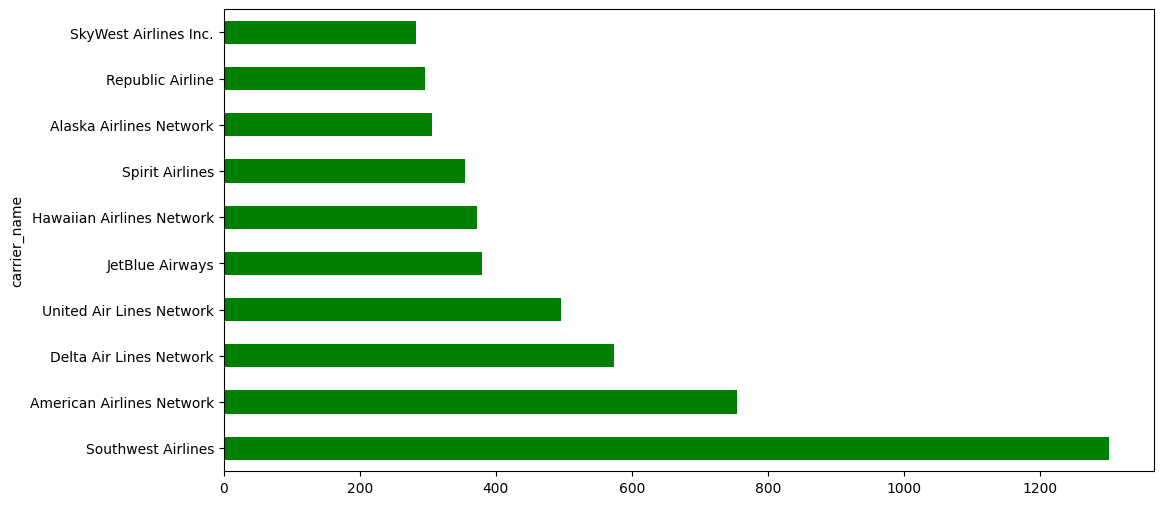

In [15]:
recovery_by_month = filtered_pre.groupby('carrier_name')['arr_flights'].mean().nlargest(10)

recovery_by_month.plot(kind = 'barh', color='green', figsize=(12, 6))

<Axes: ylabel='carrier_name'>

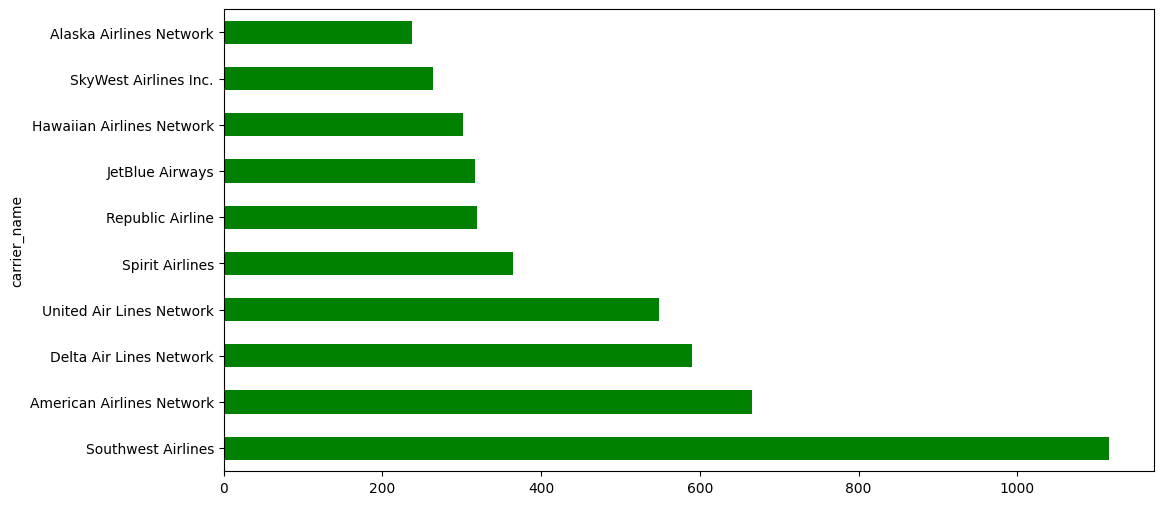

In [134]:
cancellation_by_month = filtered_post.groupby('carrier_name')['arr_flights'].mean().nlargest(10)

cancellation_by_month.plot(kind = 'barh', color='green', figsize=(12, 6))

<Axes: ylabel='carrier_name'>

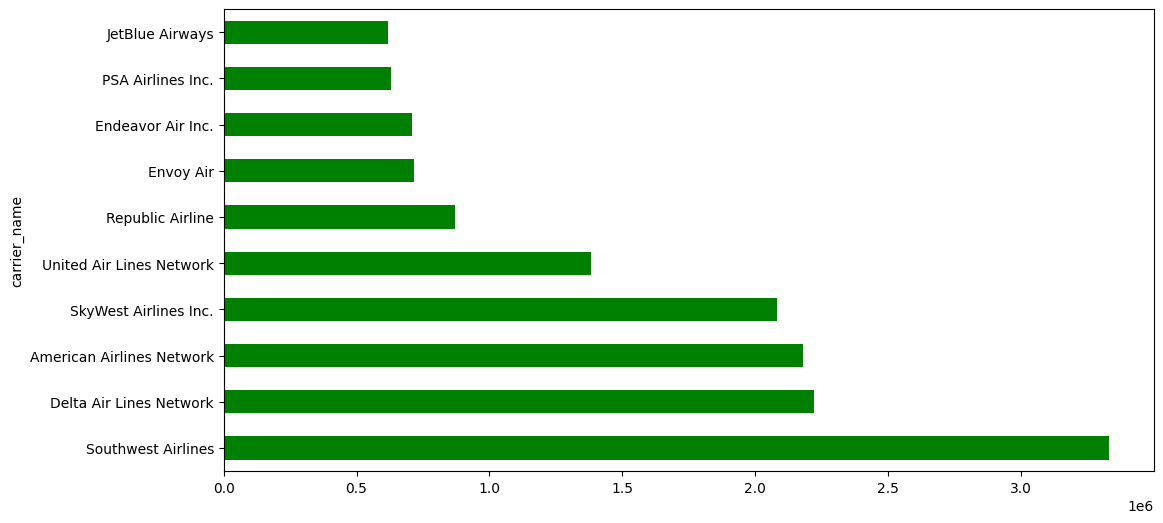

In [135]:
recovery_by_month = filtered_covid.groupby('carrier_name')['arr_flights'].sum().nlargest(10)

recovery_by_month.plot(kind = 'barh', color='green', figsize=(12, 6))

<Axes: ylabel='carrier_name'>

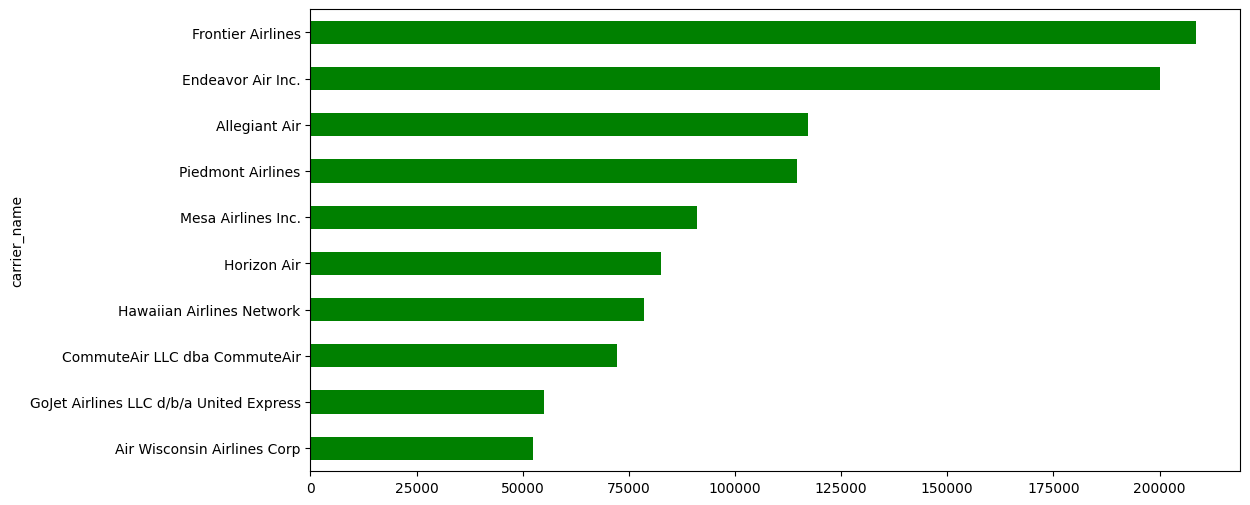

In [136]:
recovery_by_month = filtered_post.groupby('carrier_name')['arr_flights'].sum().nsmallest(10)

recovery_by_month.plot(kind = 'barh', color='green', figsize=(12, 6))

In [16]:
#filtered_pre = recovery[recovery['year'].isin([2018, 2019])]

pre = filtered_pre.groupby('carrier_name')['arr_flights'].sum()
post = filtered_post.groupby('carrier_name')['arr_flights'].sum()

In [ ]:
comparison = pd.concat([pre, post], axis=1)
comparison.columns = ['Pre-COVID', 'Post-COVID']

comparison = comparison.dropna().sort_values(by='Pre-COVID', ascending=False).head(20)
comparison = comparison.reset_index()


In [27]:
fig = px.bar(
    comparison,
    x='carrier_name',
    y=['Pre-COVID', 'Post-COVID'],
    barmode='group',
    title='Pre vs Post COVID Flight Volume by Airline (Top 10 Airlines)',
    labels={'value': 'Average Flights', 'carrier_name': 'Airline'}
)

fig.show()

In [102]:
comparison2 = pd.concat([pre, post], axis=1)
comparison2.columns = ['Pre-COVID', 'Post-COVID']

comparison2 = comparison2.dropna().sort_values(by='Pre-COVID', ascending=True).head(20)
comparison2 = comparison2.reset_index()

In [103]:
fig = px.bar(
    comparison2,
    x='carrier_name',
    y=['Pre-COVID', 'Post-COVID'],
    barmode='group',
    title='Pre vs Post COVID Flight Volume (Bottom 10 Airlines)',
    labels={'value': 'Average Flights', 'carrier_name': 'Airline'}
)

fig.show()

In [36]:
comparison['Recovery Rate'] = comparison['Post-COVID'] / comparison['Pre-COVID']

In [59]:
color_map = {
    'Frontier Airines': 'red',
    'Spirit Airlines': 'red',
    'Allegiant Air': 'red'
}

fig = px.bar(
    comparison.sort_values('Recovery Rate'),
    x='Recovery Rate',
    y='carrier_name',
    orientation='h',
    #color='carrier_name',
    #color_discrete_map=color_map,
    title='Airline Recovery Rate (Post COVID)',
    labels={'carrier_name': 'Airlines'}
)
fig.update_layout(height=600)
#fig.update_layout(height=400 + len(comparison) * 40)
fig.show()

In [70]:
highlight_airlines = ['Frontier Airlines', 'Spirit Airlines', 'Allegiant Air']

comparison['Airline_Group'] = comparison['carrier_name'].apply(
    lambda x: x if x in highlight_airlines else 'Other'
)

In [71]:
fig = px.bar(
    comparison.sort_values('Recovery Rate'),
    x='Recovery Rate',
    y='carrier_name',
    orientation='h',
    color='Airline_Group',
    color_discrete_map={
        'Frontier Airlines': 'red',
        'Spirit Airlines': 'red',
        'Allegiant Air': 'red',
        'Other': 'blue'
    },
    title='Airline Recovery Rate (Post COVID)'
)

fig.update_layout(height=600)
fig.show()

In [78]:
low_airlines = ['Frontier Airlines', 'Spirit Airlines', 'Allegiant Air']

comparison['category'] = comparison['carrier_name'].apply(
    lambda x: 'Regional' if x in low_airlines else 'Other'
)

In [ ]:
fig = px.bar(
    comparison.sort_values('Recovery Rate'),
    x='Recovery Rate',
    y='carrier_name',
    orientation='h',
    color='category',   
    color_discrete_map={
        'Regional': 'red',
        'Other': 'blue'
    },
    title='Airline Recovery Rate (Post COVID)'
)

fig.update_layout(height=600)
fig.show()

In [94]:
big_4 = [
    'United Air Lines Network',
    'American Airlines Network',
    'Southwest Airlines',
    'Delta Air Lines Network'
]

In [95]:
comparison['category'] = comparison['carrier_name'].apply(
    lambda x: 'Big 4' if x in big_4
    else 'Ultra Low Budget' if x in low_airlines
    else 'Regional & Mid-Tier'
)

In [96]:
fig = px.bar(
    comparison.sort_values('Recovery Rate'),
    x='Recovery Rate',
    y='carrier_name',
    orientation='h',
    color='category',
    color_discrete_map={
        'Big 4': 'green',
        'Ultra Low Budget': 'red',
        'Regional & Mid-Tier': 'lightblue'
    },
    title='Airline Recovery Rate (Post COVID)'
)

fig.update_layout(
    height=600,
    legend_title_text='Airline Group'
)

fig.show()